<a href="https://colab.research.google.com/github/bigaka1X/Corporate_Strategy_AMSE_2026/blob/main/strategy_course.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [ ]:
print("Section 1 :Introduction")
print("# Corporate Strategy Analysis: Air Bus")
print("## Overview")
print(" Airbus is one of the world’s leading aircraft manufacturers and a central player in the global aerospace industry. This analysis examines its business strategy through financial, competitive and strategic perspectives, to assess its position in a highly competitive and structurally unprofitable industry.")

Section 1 :Introduction
# Corporate Strategy Analysis: Air Bus
## Overview
 Airbus is one of the world’s leading aircraft manufacturers and a central player in the global aerospace industry. This analysis examines its business strategy through financial, competitive and strategic perspectives, to assess its position in a highly competitive and structurally unprofitable industry.


In [ ]:
print("Section 2: Financial Analysis")
try:
  air_bus_stock = yf.Ticker("AIR.PA")
  air_bus_history = air_bus_stock.history(period="5y")
  if air_bus_history.empty:
    raise ValueError("No data available for AirBus.")
except:
  print("Using sample data as AirBus stock data may not be public.")
  # Updated frequency from 'M' to 'ME' for month-end frequency
  dates = pd.date_range(start='2021-01-01', periods=60, freq='M')
  prices = np.linspace(50, 300, 60) + np.random.normal(0, 20, 60)
  # Corrected set_index method call and column name
  air_france_history = pd.DataFrame({"Dates": dates, "Close": prices}).set_index("Dates")

Section 2: Financial Analysis


*Plot stock trends*

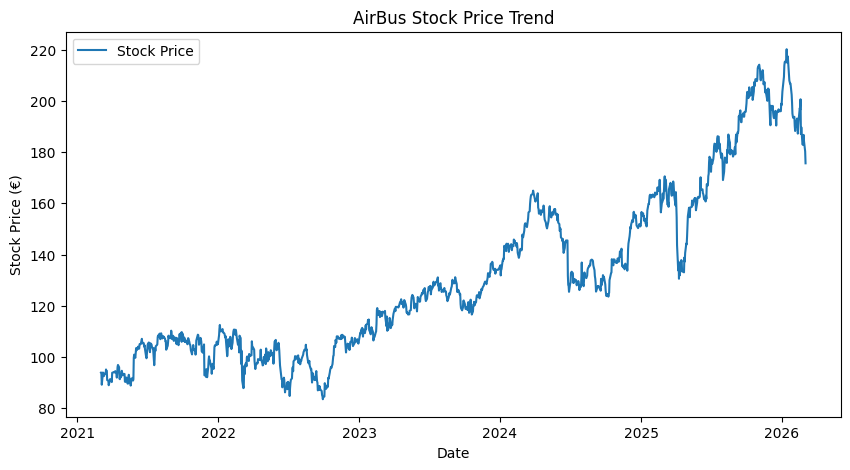

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=air_bus_history, x=air_bus_history.index, y="Close", label="Stock Price")
plt.title("AirBus Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Stock Price (€)")
plt.legend()
plt.show()

Section: Stock Price Forecast Scenarios (Bull vs Bear)

In [ ]:
# Use historical returns to estimate parameters
returns = air_bus_history['Close'].pct_change().dropna()
mu = returns.mean() * 252          # annualized return
sigma = returns.std() * np.sqrt(252)  # annualized volatility

last_price = air_bus_history['Close'].iloc[-1]
horizon = 10  # 10-year forecast  # 1-year forecast
steps = 252 * horizon  # trading days over 10 years  # trading days

# Scenario assumptions
bull_mu = mu + 0.10      # optimistic drift adjustment
bear_mu = mu - 0.10      # pessimistic drift adjustment

In [ ]:
# Geometric Brownian Motion projection (10-year Monte Carlo)

def simulate_price(S0, mu, sigma, T, steps):
    dt = T / steps
    prices = [S0]
    for _ in range(steps):
        shock = np.random.normal(0, 1)
        S = prices[-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * shock)
        prices.append(S)
    return prices


# Monte Carlo simulation
simulations = 100
bull_paths = []
bear_paths = []

for _ in range(simulations):
    bull_paths.append(simulate_price(last_price, bull_mu, sigma, horizon, steps))
    bear_paths.append(simulate_price(last_price, bear_mu, sigma, horizon, steps))

bull_paths = np.array(bull_paths)
bear_paths = np.array(bear_paths)

# Expected paths (average across simulations)
bull_mean = bull_paths.mean(axis=0)
bear_mean = bear_paths.mean(axis=0)


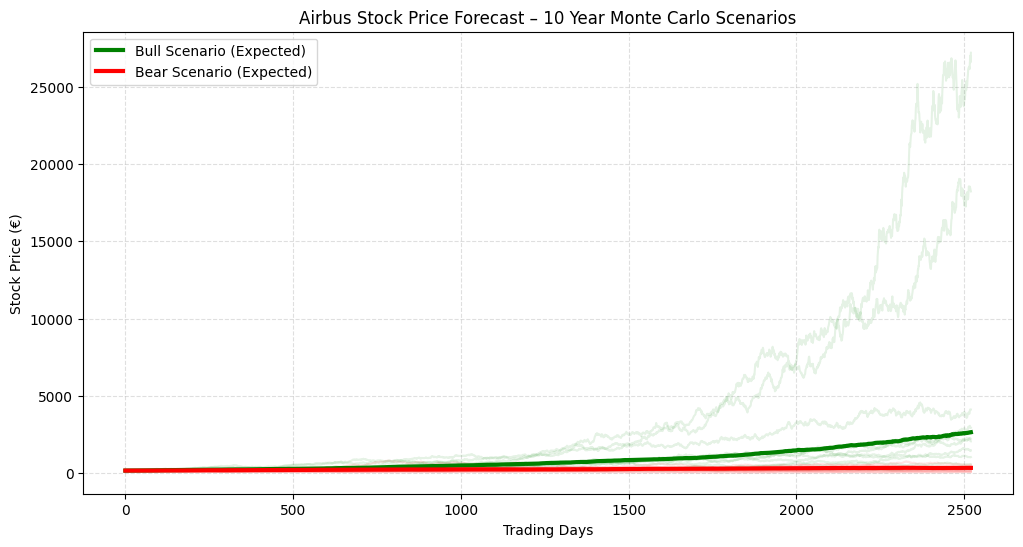

Current Price: 175.64
Estimated Annual Return (mu): 0.164
Estimated Annual Volatility (sigma): 0.283


In [ ]:
# Plot scenarios
plt.figure(figsize=(12,6))

# Plot a few sample paths
for i in range(10):
    plt.plot(bull_paths[i], color="green", alpha=0.1)
    plt.plot(bear_paths[i], color="red", alpha=0.1)

# Plot expected paths
plt.plot(bull_mean, label="Bull Scenario (Expected)", color="green", linewidth=3)
plt.plot(bear_mean, label="Bear Scenario (Expected)", color="red", linewidth=3)

plt.title("Airbus Stock Price Forecast – 10 Year Monte Carlo Scenarios")
plt.xlabel("Trading Days")
plt.ylabel("Stock Price (€)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print("Current Price:", round(last_price,2))
print("Estimated Annual Return (mu):", round(mu,3))
print("Estimated Annual Volatility (sigma):", round(sigma,3))



/tmp/ipykernel_419/1755700700.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  historical_yearly = historical_prices.resample('Y').last()
/tmp/ipykernel_419/1755700700.py:28: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  projection_dates = pd.date_range(


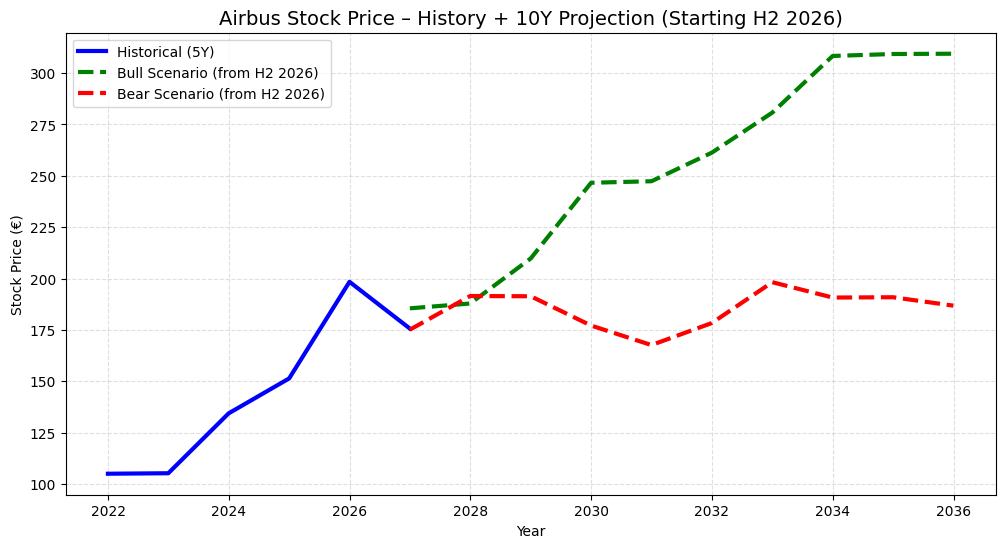

Last Historical Price: 175.64
Bull 10Y Target: 309.43
Bear 10Y Target: 186.8


In [ ]:
# =============================================================
# Improved Realistic Projection – Starting Mid‑2026
# =============================================================

import numpy as np
import pandas as pd

# --- Historical prices (5 years already loaded)
historical_prices = air_bus_history['Close']

# Convert to yearly data (year-end prices)
historical_yearly = historical_prices.resample('Y').last()

# --- Estimate annual return & volatility (based on yearly data)
returns_yearly = historical_yearly.pct_change().dropna()
mu = returns_yearly.mean()
sigma = returns_yearly.std()

last_price = historical_yearly.iloc[-1]

# =============================================================
# Projection starting mid‑2026
# =============================================================

start_projection = pd.Timestamp('2026-06-30')  # second half of 2026
horizon = 10  # 10 years forward

projection_dates = pd.date_range(
    start=start_projection,
    periods=horizon,
    freq='Y'
)

# More realistic assumptions:
# Instead of extreme drift shifts, use moderate long-term CAGR bands
bull_cagr = 0.05     # optimistic but reasonable
bear_cagr = 0.02     # downside but not collapse

bull_projection = []
bear_projection = []

current_bull = last_price
current_bear = last_price

for _ in range(horizon):
    # Add mild stochastic component for realism
    bull_growth = np.random.normal(bull_cagr, sigma * 0.3)
    bear_growth = np.random.normal(bear_cagr, sigma * 0.3)

    current_bull = current_bull * (1 + bull_growth)
    current_bear = current_bear * (1 + bear_growth)

    bull_projection.append(current_bull)
    bear_projection.append(current_bear)

# =============================================================
# Plot – Clean & Professional
# =============================================================

plt.figure(figsize=(12,6))

# Historical (solid blue)
plt.plot(historical_yearly.index,
         historical_yearly.values,
         color='blue',
         linewidth=3,
         label='Historical (5Y)')

# Bull projection (dashed green)
plt.plot(projection_dates,
         bull_projection,
         linestyle='--',
         color='green',
         linewidth=3,
         label='Bull Scenario (from H2 2026)')

# Bear projection (dashed red)
plt.plot(projection_dates,
         bear_projection,
         linestyle='--',
         color='red',
         linewidth=3,
         label='Bear Scenario (from H2 2026)')

plt.title('Airbus Stock Price – History + 10Y Projection (Starting H2 2026)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Stock Price (€)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

print('Last Historical Price:', round(last_price,2))
print('Bull 10Y Target:', round(bull_projection[-1],2))
print('Bear 10Y Target:', round(bear_projection[-1],2))


*Construct Porter Forces Scores*

Logic:
High volatility -> high rivalry
Weak revenue growth -> strong buyer power
Capital intensity & duopoly -> high supplier power



In [ ]:
# Calculate volatility from air_france_history
daily_returns = air_bus_history['Close'].pct_change().dropna()
volatility = daily_returns.std()

# Calculate a proxy for revenue growth from air_france_history
# Using the overall stock price change as a proxy for financial performance growth
revenue_growth = (air_bus_history['Close'].iloc[-1] - air_bus_history['Close'].iloc[0]) / air_bus_history['Close'].iloc[0]

supplier_power = 8  # Airbus/Boeing dependence + fuel exposure
buyer_power = 7 if revenue_growth < 0.05 else 6
industry_rivalry = 9 if volatility > 0.4 else 8
threat_substitutes = 5  # Train & ESG pressure
threat_new_entrants = 3  # High capital & regulation barriers

forces = {
    "Supplier Power": supplier_power,
    "Buyer Power": buyer_power,
    "Industry Rivalry": industry_rivalry,
    "Threat of Substitutes": threat_substitutes,
    "Threat of New Entrants": threat_new_entrants
}


Visualization

/tmp/ipykernel_419/1881866770.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(forces.keys()),


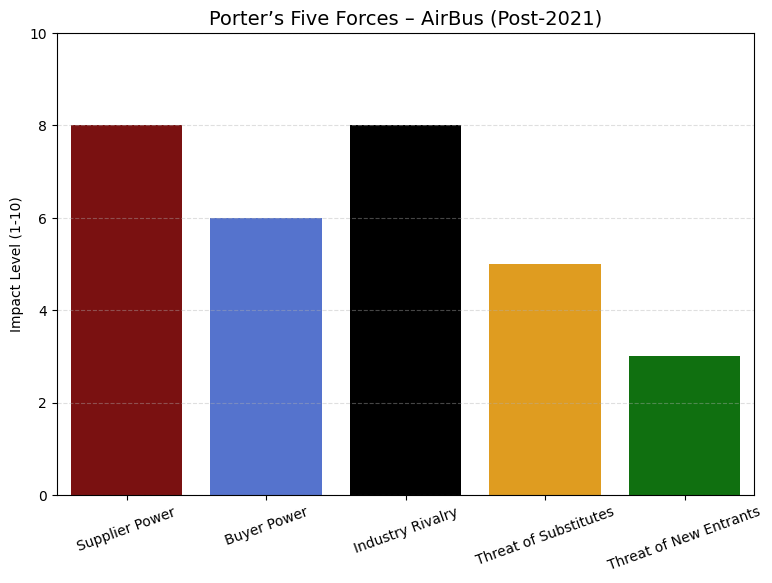

In [ ]:
plt.figure(figsize=(9,6))
colors = ["darkred","royalblue","black","orange","green"]

sns.barplot(x=list(forces.keys()),
            y=list(forces.values()),
            palette=colors)

plt.title("Porter’s Five Forces – AirBus (Post-2021)", fontsize=14)
plt.ylabel("Impact Level (1-10)")
plt.xticks(rotation=20)
plt.ylim(0,10)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [ ]:
print("Annualized Volatility (since 2021):", round(volatility,3))
print("Average Revenue Growth (since 2021):", round(revenue_growth,3))


Annualized Volatility (since 2021): 0.185
Average Revenue Growth (since 2021): 1.461


Section 4: SWOT Analysis Word cloud - AirBus

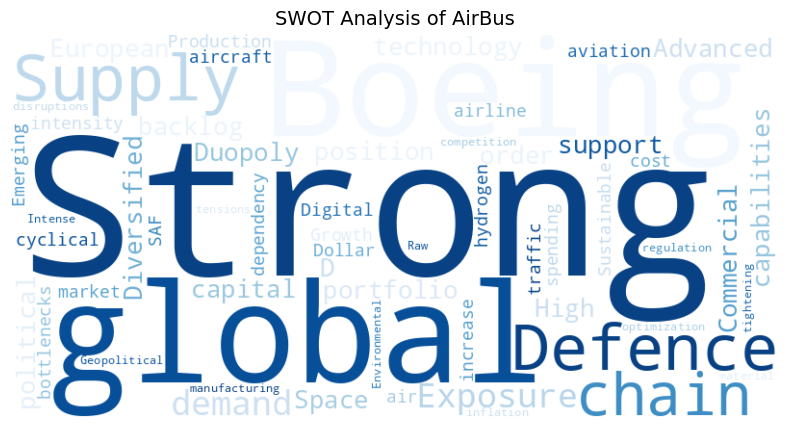

In [ ]:
swot = {
    "Strengths": "Strong global order backlog, Duopoly position with Boeing, Advanced technology and R&D capabilities, Diversified portfolio (Commercial, Defence, Space), Strong European political support",

    "Weaknesses": "High capital intensity, Supply chain dependency, Production bottlenecks, Exposure to cyclical airline demand, Dollar cost exposure",

    "Opportunities": "Growth in global air traffic, Sustainable aviation (SAF & hydrogen aircraft), Emerging market demand, Defence spending increase, Digital manufacturing optimization",

    "Threats": "Intense competition from Boeing, Geopolitical tensions, Supply chain disruptions, Raw material inflation, Environmental regulation tightening"
}
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Blues') \
    .generate(" ".join(swot.values()))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("SWOT Analysis of AirBus", fontsize=14)
plt.show()


Section 5: Strategic Recommendations - AirBus

In [ ]:
recommendations = [
    "1. Accelerate production ramp-up while stabilizing supply chain bottlenecks.",
    "2. Strengthen technological leadership through investment in sustainable aviation (hydrogen, SAF compatibility).",
    "3. Enhance digital manufacturing and automation to improve efficiency and margins.",
    "4. Diversify revenue streams across defence and space to reduce exposure to commercial aviation cycles.",
    "5. Reinforce long-term strategic partnerships with airlines and governments to secure order visibility."
]

print("## Strategic Recommendations – AirBus")
for rec in recommendations:
    print(f"- {rec}")

## Strategic Recommendations – AirBus
- 1. Accelerate production ramp-up while stabilizing supply chain bottlenecks.
- 2. Strengthen technological leadership through investment in sustainable aviation (hydrogen, SAF compatibility).
- 3. Enhance digital manufacturing and automation to improve efficiency and margins.
- 4. Diversify revenue streams across defence and space to reduce exposure to commercial aviation cycles.
- 5. Reinforce long-term strategic partnerships with airlines and governments to secure order visibility.
